<a href="https://colab.research.google.com/github/LadyDbug/AI-Expert-Course/blob/main/Digit_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Select*** Runtime***. Select ***Change runtime type***. In the dialog that opens, select ***Hardware accelerator*** as **GPU** -GPU stands for Graphics processing Unit. Google provides the use of free GPU for your Colab notebooks. This speeds up the execution. On the top right of the Notebook screen, click ***CONNECT*** and select ***Connect to hosted runtime***

In [ ]:
from keras.datasets import mnist

#download mnist data and split into train and test sets - x_train and x_test are arrays of train and test input images respectively.
# y_train and y_test are train and test labels respectively.
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Save original test images for display purposes
orig_test = x_test


Label is:  5


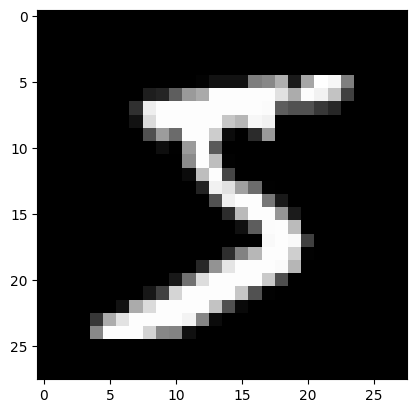

In [ ]:
import matplotlib.pyplot as plt
#plot the first image in the training dataset -->Images are represented as a 28 x 28 matrix of pixel values.
plt.imshow(x_train[0],cmap='gray')
print('Label is: ',y_train[0])
plt.show()

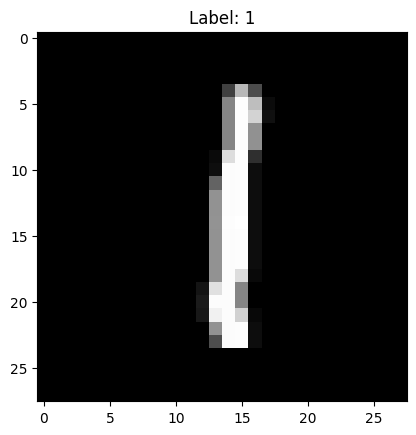

In [ ]:
#The following code displays random test images from the test data.

import random
index = random.randint(0,1000)
plt.imshow(x_test[index], cmap='gray')
plt.title('Label: %d' % y_test[index])
plt.show()

In [ ]:
#check image shape
x_train[0].shape

(28, 28)

Next, we need to reshape our dataset inputs (x_train and x_test) to the shape that our model expects when we train the model. The first number is the number of images (60,000 for x_train and 10,000 for x_test). Then comes the shape of each image (28x28). The last number is 1, which signifies that the images are greyscale.

In [ ]:
#reshape data to fit model
x_train = x_train.reshape(60000,28,28,1)
x_test = x_test.reshape(10000,28,28,1)

We need to ‘**one-hot-encode**’ our target variable. This means that a column will be created for each output category and a binary variable is inputted for each category. For example, we saw that the first image in the dataset is a 5. This means that the sixth number in our array will have a 1 and the rest of the array will be filled with 0.

In [ ]:
from tensorflow.keras.utils import to_categorical
#one-hot encode target column
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [ ]:
# %tensorflow_version 2.x
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten
#create model
model = Sequential()
#add model layers
model.add(Conv2D(64, kernel_size=3, activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32, kernel_size=3, activation='relu'))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

In [ ]:
#compile model using accuracy to measure model performance
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#train the model
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9511 - loss: 0.2390 - val_accuracy: 0.9741 - val_loss: 0.0948
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9783 - loss: 0.0702 - val_accuracy: 0.9729 - val_loss: 0.0988
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9852 - loss: 0.0487 - val_accuracy: 0.9718 - val_loss: 0.0992


This is going to look at the images in the test data, and predict them


In [ ]:
# predict first 4 images in the test set
#returns the set of probability values for each digit from 0 to 9
#the digit with the highest probability will be the one predicted

model.predict(x_test[:4])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step


array([[2.51310944e-10, 3.59641397e-12, 1.58386353e-08, 5.78445088e-06,
        5.80822960e-14, 1.22733533e-11, 6.82385057e-14, 9.99994159e-01,
        3.90749699e-09, 1.94517042e-08],
       [4.65215498e-06, 1.07632616e-07, 9.99130785e-01, 2.84448048e-10,
        3.13903814e-09, 2.94599349e-12, 8.64457514e-04, 6.89093964e-13,
        2.17128662e-08, 1.10848925e-13],
       [7.39111329e-07, 9.97655392e-01, 7.37232767e-06, 8.36461123e-09,
        1.10955082e-03, 2.22641148e-07, 9.80663845e-06, 9.29769813e-05,
        1.12404407e-03, 9.94057547e-09],
       [9.99999404e-01, 4.94167915e-15, 2.37229152e-08, 9.15876316e-12,
        1.82441479e-10, 8.55720401e-08, 4.30441020e-07, 1.48136492e-09,
        1.23940707e-08, 4.92695911e-08]], dtype=float32)

In [ ]:
b=model.predict(x_test[:4])
print(b)
a=b.argmax(1)
print(a)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[2.51310944e-10 3.59641397e-12 1.58386353e-08 5.78445088e-06
  5.80822960e-14 1.22733533e-11 6.82385057e-14 9.99994159e-01
  3.90749699e-09 1.94517042e-08]
 [4.65215498e-06 1.07632616e-07 9.99130785e-01 2.84448048e-10
  3.13903814e-09 2.94599349e-12 8.64457514e-04 6.89093964e-13
  2.17128662e-08 1.10848925e-13]
 [7.39111329e-07 9.97655392e-01 7.37232767e-06 8.36461123e-09
  1.10955082e-03 2.22641148e-07 9.80663845e-06 9.29769813e-05
  1.12404407e-03 9.94057547e-09]
 [9.99999404e-01 4.94167915e-15 2.37229152e-08 9.15876316e-12
  1.82441479e-10 8.55720401e-08 4.30441020e-07 1.48136492e-09
  1.23940707e-08 4.92695911e-08]]
[7 2 1 0]


In [ ]:
# #actual results for first 4 images in test set
y_test[:4]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
predictions = model.predict(x_test)
print(predictions)
print(len(predictions)) #number of rows in predictions array--->since test data is 10000 images


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[2.51310944e-10 3.59642763e-12 1.58386957e-08 ... 9.99994159e-01
  3.90751165e-09 1.94517416e-08]
 [4.65215953e-06 1.07632822e-07 9.99130785e-01 ... 6.89092663e-13
  2.17129088e-08 1.10849135e-13]
 [7.39111329e-07 9.97655392e-01 7.37234177e-06 ... 9.29771559e-05
  1.12404616e-03 9.94061367e-09]
 ...
 [1.16508037e-15 8.24469995e-13 1.90408192e-17 ... 1.34209344e-09
  2.11742554e-10 4.08584500e-10]
 [6.08984668e-11 2.14144064e-13 1.21375089e-11 ... 8.78009054e-11
  3.95533505e-07 1.85166282e-08]
 [1.80051575e-05 6.40793299e-14 2.59108390e-07 ... 4.44256096e-13
  7.00510282e-06 1.59382407e-09]]
10000


[7 2 1 ... 4 5 6]


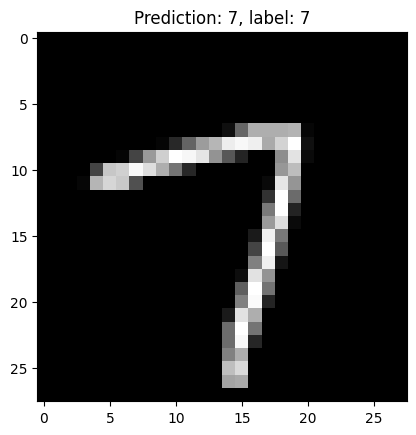

In [ ]:
import numpy as np
most_likely = np.argmax(predictions,axis=1)
print(most_likely)
index=random.randint(0,10000)
plt.title('Prediction: %d, label: %d' % (most_likely[index], y_test[index].argmax()))
plt.imshow(orig_test[index], cmap='gray')
plt.show()